Life Cycle
-Understanding Problem statement
-Data collection
-Data checks
-Exploratory Data Analysis
-Data Pre-Processing
-Model Training
-Choose best model

1. Problem Statement
Understand how there being a run in the first inning of an mlb game is affected by other variables such as Leadoff hitter stats, venue, and pitching stats (very simple right now)

In [4]:
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [28]:
df = pd.read_csv('/Users/trevorpowell/mlproject/notebook/data/mlb_game_data.csv')

In [29]:
df.head()

,game_id,date,venue,home_team,away_team,home_leadoff_avg,away_leadoff_avg,home_starting_pitcher_era,away_starting_pitcher_era,first_inning_run
0,777909,2025-05-15,Truist Park,Atlanta Braves,Washington Nationals,0.247,0.317,2.33,5.91,False
1,777911,2025-05-15,Oriole Park at Camden Yards,Baltimore Orioles,Minnesota Twins,0.250,0.261,3.08,4.05,False
2,777912,2025-05-15,Great American Ball Park,Cincinnati Reds,Chicago White Sox,0.291,0.221,3.66,6.00,True
3,777913,2025-05-15,Rogers Centre,Toronto Blue Jays,Tampa Bay Rays,0.290,0.571,4.59,4.31,True
4,777910,2025-05-15,Globe Life Field,Texas Rangers,Houston Astros,0.306,0.313,2.29,1.43,False


In [36]:
df['first_inning_run'] = df['first_inning_run'].astype(int)

In [37]:
df.head()

,game_id,date,venue,home_team,away_team,home_leadoff_avg,away_leadoff_avg,home_starting_pitcher_era,away_starting_pitcher_era,first_inning_run
0,777909,2025-05-15,Truist Park,Atlanta Braves,Washington Nationals,0.247,0.317,2.33,5.91,0
1,777911,2025-05-15,Oriole Park at Camden Yards,Baltimore Orioles,Minnesota Twins,0.250,0.261,3.08,4.05,0
2,777912,2025-05-15,Great American Ball Park,Cincinnati Reds,Chicago White Sox,0.291,0.221,3.66,6.00,1
3,777913,2025-05-15,Rogers Centre,Toronto Blue Jays,Tampa Bay Rays,0.290,0.571,4.59,4.31,1
4,777910,2025-05-15,Globe Life Field,Texas Rangers,Houston Astros,0.306,0.313,2.29,1.43,0


In [30]:
df.shape

(1158, 10)

In [31]:
df.isna().sum()

game_id                      0
date                         0
venue                        0
home_team                    0
away_team                    0
home_leadoff_avg             0
away_leadoff_avg             0
home_starting_pitcher_era    0
away_starting_pitcher_era    0
first_inning_run             0
dtype: int64

In [32]:
df.duplicated().sum()

np.int64(0)

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1158 entries, 0 to 1157
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   game_id                    1158 non-null   int64  
 1   date                       1158 non-null   object 
 2   venue                      1158 non-null   object 
 3   home_team                  1158 non-null   object 
 4   away_team                  1158 non-null   object 
 5   home_leadoff_avg           1158 non-null   float64
 6   away_leadoff_avg           1158 non-null   float64
 7   home_starting_pitcher_era  1158 non-null   float64
 8   away_starting_pitcher_era  1158 non-null   float64
 9   first_inning_run           1158 non-null   bool   
dtypes: bool(1), float64(4), int64(1), object(4)
memory usage: 82.7+ KB


In [34]:
df.nunique()

game_id                      1154
date                           87
venue                          31
home_team                      30
away_team                      30
home_leadoff_avg              144
away_leadoff_avg              145
home_starting_pitcher_era     473
away_starting_pitcher_era     481
first_inning_run                2
dtype: int64

In [35]:
df.describe()

,game_id,home_leadoff_avg,away_leadoff_avg,home_starting_pitcher_era,away_starting_pitcher_era
count,1158.000000,1158.000000,1158.000000,1158.000000,1158.000000
mean,777337.166667,0.272458,0.274064,4.041572,4.087824
std,337.036686,0.029499,0.032908,1.534392,1.623990
min,776746.000000,0.100000,0.118000,0.710000,0.790000
25%,777046.250000,0.254000,0.257000,3.062500,3.070000
50%,777335.500000,0.271000,0.273000,3.950000,3.860000
75%,777625.750000,0.288000,0.288750,4.740000,4.810000
max,778431.000000,0.500000,0.600000,18.000000,13.850000


In [38]:
df['first_inning_run'].value_counts(normalize=True)

first_inning_run
0    0.501727
1    0.498273
Name: proportion, dtype: float64

In [39]:
df.groupby('first_inning_run').mean(numeric_only=True)

,game_id,home_leadoff_avg,away_leadoff_avg,home_starting_pitcher_era,away_starting_pitcher_era
first_inning_run,,,,,
0,777341.271945,0.271031,0.273967,3.891807,3.949914
1,777333.032929,0.273894,0.274161,4.192374,4.226690


In [40]:
pd.crosstab(df['venue'], df['first_inning_run'], normalize='index')

first_inning_run,0,1
venue,,
American Family Field,0.651163,0.348837
Angel Stadium,0.465116,0.534884
Bristol Motor Speedway,0.000000,1.000000
Busch Stadium,0.512195,0.487805
Chase Field,0.351351,0.648649
Citi Field,0.500000,0.500000
Citizens Bank Park,0.583333,0.416667
Comerica Park,0.487805,0.512195
Coors Field,0.351351,0.648649


<Axes: xlabel='venue', ylabel='first_inning_run'>

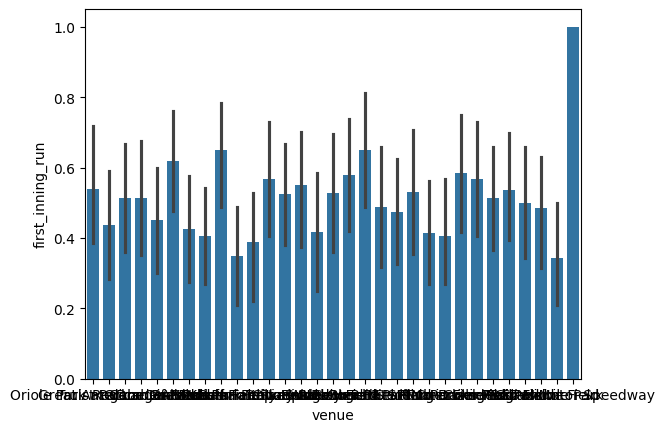

In [41]:
sns.barplot(data=df, x='venue', y='first_inning_run')

<Axes: xlabel='home_leadoff_avg', ylabel='away_starting_pitcher_era'>

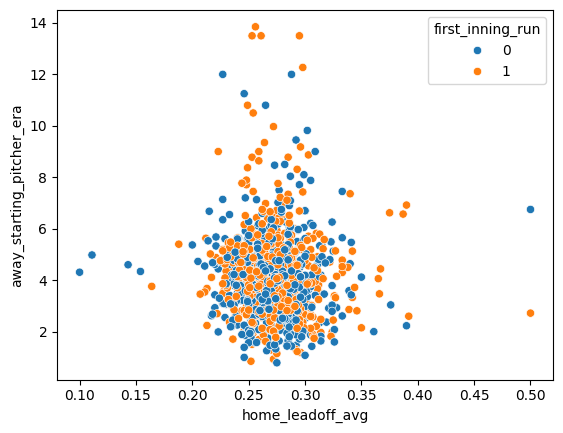

In [42]:
sns.scatterplot(data=df, x='home_leadoff_avg', y='away_starting_pitcher_era', hue='first_inning_run')